In [1]:
!pip install -q google-generativeai

import google.generativeai as genai
import numpy as np
import pandas as pd
from math import ceil
import time

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [2]:
df = pd.read_csv('./sample_data/MalBehavD-V1-dataset.csv')

api_cols = [str(i) for i in range(151)]
df['api_sequence'] = df[api_cols].apply(
    lambda row: ' '.join([x for x in row if pd.notna(x) and x != '']), axis=1
)

sequences = df['api_sequence'].tolist()
labels = df['labels'].tolist()

print(f'Total secuencias: {len(sequences)}')

Total secuencias: 2570


In [ ]:
from itertools import cycle

api_keys = ['', '', '', '']
key_cycle = cycle(api_keys)
current_key = next(key_cycle)
genai.configure(api_key=current_key)

BATCH_SIZE = 100
all_embeddings = []

for i in range(0, len(sequences), BATCH_SIZE):
    batch = sequences[i:i+BATCH_SIZE]
    intentos = 0
    while True:
        try:
            result = genai.embed_content(
                model='models/gemini-embedding-001',
                content=batch,
                task_type='CLASSIFICATION'
            )
            all_embeddings.extend(result['embedding'])
            print(f'Batch {i//BATCH_SIZE + 1}/{ceil(len(sequences)/BATCH_SIZE)} completado con key ...{current_key[-6:]}')
            time.sleep(2)
            break
        except Exception as e:
            intentos += 1
            if intentos >= 4:
                current_key = next(key_cycle)
                genai.configure(api_key=current_key)
                intentos = 0
                print(f'Cambiando a key ...{current_key[-6:]}')
            else:
                print(f'Rate limit (intento {intentos}/4), esperando 65s...')
                time.sleep(65)

X = np.array(all_embeddings)
y = np.array(labels)
print(f'Shape embeddings: {X.shape}')

Batch 1/26 completado con key ...8MHfgM


Rate limit (intento 1/4), esperando 65s...
Batch 2/26 completado con key ...8MHfgM


Rate limit (intento 1/4), esperando 65s...
Batch 3/26 completado con key ...8MHfgM


Rate limit (intento 1/4), esperando 65s...
Batch 4/26 completado con key ...8MHfgM


Rate limit (intento 1/4), esperando 65s...
Batch 5/26 completado con key ...8MHfgM


...

Rate limit (intento 1/4), esperando 65s...
Batch 21/26 completado con key ...w1e2OE


Rate limit (intento 1/4), esperando 65s...
Batch 22/26 completado con key ...w1e2OE


Rate limit (intento 1/4), esperando 65s...
Batch 23/26 completado con key ...w1e2OE
Batch 24/26 completado con key ...w1e2OE


Rate limit (intento 1/4), esperando 65s...
Batch 25/26 completado con key ...w1e2OE


Rate limit (intento 1/4), esperando 65s...
Batch 26/26 completado con key ...w1e2OE
Shape embeddings: (2570, 3072)


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_curve, auc, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 827,905 (3.16 MB)

 Trainable params: 827,905 (3.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.5069 - loss: 0.6874 - val_accuracy: 0.7833 - val_loss: 0.5093
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8206 - loss: 0.4422 - val_accuracy: 0.8833 - val_loss: 0.2413
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9101 - loss: 0.2367 - val_accuracy: 0.8944 - val_loss: 0.2365
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9235 - loss: 0.2118 - val_accuracy: 0.9167 - val_loss: 0.2258
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9295 - loss: 0.2020 - val_accuracy: 0.9167 - val_loss: 0.2125
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9238 - loss: 0.2040 - val_accuracy: 0.9111 - val_loss: 0.2093
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9316 - loss: 0.1952 - val_accuracy: 0.9278 - val_loss: 0.2054
Epoch 8/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9414 - loss: 0.1758 - val_accuracy: 0.9333 - v

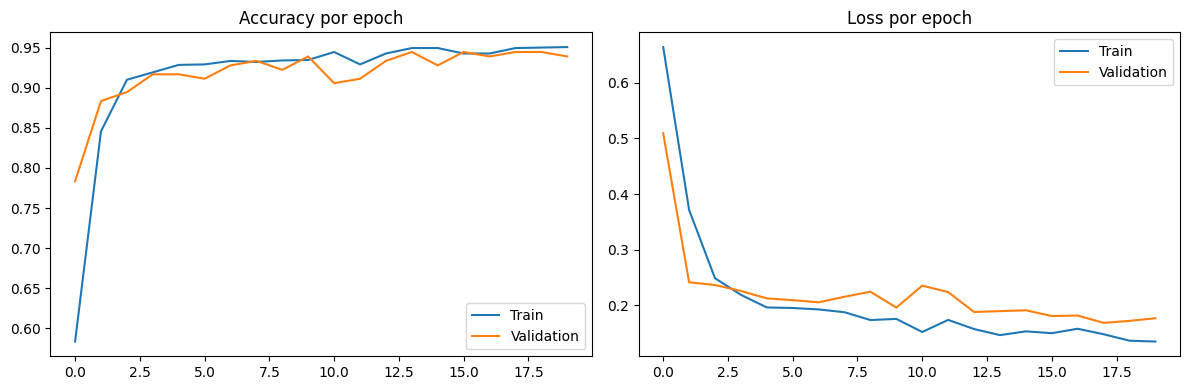

In [12]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy por epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss por epoch')
plt.legend()

plt.tight_layout()
plt.savefig('training_history_modelo2.png', dpi=150)
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
=== Classification Report ===
              precision    recall  f1-score   support

     Benigno       0.90      0.98      0.94       386
     Malware       0.98      0.90      0.93       385

    accuracy                           0.94       771
   macro avg       0.94      0.94      0.94       771
weighted avg       0.94      0.94      0.94       771



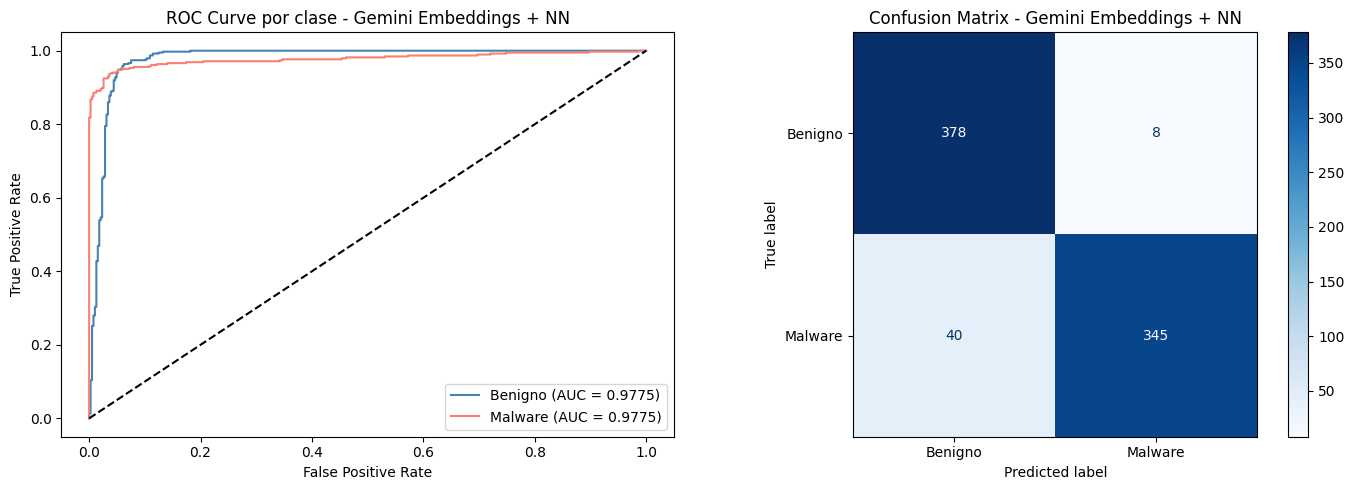

In [13]:
y_prob = model.predict(X_test).flatten()
y_pred = (y_prob >= 0.5).astype(int)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Benigno', 'Malware']))

fpr_b, tpr_b, _ = roc_curve(1 - y_test, 1 - y_prob)
auc_b = auc(fpr_b, tpr_b)
fpr_m, tpr_m, _ = roc_curve(y_test, y_prob)
auc_m = auc(fpr_m, tpr_m)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr_b, tpr_b, color='steelblue', label=f'Benigno (AUC = {auc_b:.4f})')
axes[0].plot(fpr_m, tpr_m, color='salmon', label=f'Malware (AUC = {auc_m:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve por clase - Gemini Embeddings + NN')
axes[0].legend()

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Benigno', 'Malware']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title('Confusion Matrix - Gemini Embeddings + NN')

plt.tight_layout()
plt.savefig('resultados_modelo2.png', dpi=150)
plt.show()

In [15]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), 1):
    X_fold_train, X_fold_val = X[train_idx], X[val_idx]
    y_fold_train, y_fold_val = y[train_idx], y[val_idx]

    fold_model = keras.Sequential([
        layers.Input(shape=(X.shape[1],)),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    fold_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    fold_model.fit(X_fold_train, y_fold_train, epochs=20, batch_size=32, verbose=0)

    y_fold_pred = (fold_model.predict(X_fold_val, verbose=0).flatten() >= 0.5).astype(int)
    score = accuracy_score(y_fold_val, y_fold_pred)
    cv_scores.append(score)
    print(f'  Fold {fold:2d}: {score:.4f}')

cv_scores = np.array(cv_scores)
print(f'\n  Media:          {cv_scores.mean():.4f}')
print(f'  Desviación std: {cv_scores.std():.4f}')

  Fold  1: 0.9377
  Fold  2: 0.9650
  Fold  3: 0.9533
  Fold  4: 0.9689
  Fold  5: 0.9455
  Fold  6: 0.9455
  Fold  7: 0.9261
  Fold  8: 0.9377
  Fold  9: 0.9533
  Fold 10: 0.8988

  Media:          0.9432
  Desviación std: 0.0192
